In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [218]:
def ships_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  grouped as (select x, sum(y) over (order by x) as y from (select frame as x, sum(val) as y from combined group by frame))
  select * from grouped where x <= {max_frames} order by x;
  """)
  return result

def ships_grouped_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  partitioned as (select owner, x, sum(y) over (partition by owner order by x) as y 
  from (select owner, frame as x, sum(val) as y from combined group by frame, owner)
  )

  select * from partitioned where x <= {max_frames} order by owner, x;
                           
""")
  return result




In [219]:
get_tables()

['ships_destroyed',
 'ships_created',
 'players',
 'servers',
 'server_ticks',
 'pings',
 'player_counts']

In [220]:
def plot_all(max_frames = 999999999):
    fig, axes = plt.subplots(4, 1, figsize=(16,12), dpi=160, sharex = True)
    ticks = statement_to_df(f"select tick as x, micros_elapsed / 1000.0 as y from server_ticks where tick <= {max_frames}")
    axes[0].plot(ticks["x"], ticks["y"], )
    axes[0].set_title("Server time to calculate tick")
    axes[0].set_ylabel("Server Tick (ms)")

    pings = statement_to_df(f"select tick as x, micros / 1000.0 as y from pings where tick <= {max_frames}")
    # ping_moving_avg = pings["y"].rolling(window=5).mean()
    axes[1].plot(pings["x"], pings["y"])
    axes[1].set_title("Client ping over time")
    axes[1].set_ylabel("Ping (ms)")

    ships = ships_over_frame(max_frames)
    axes[2].plot(ships["x"], ships["y"], label="Total Ships")
    axes[2].set_title("Total ships over time")
    axes[2].set_ylabel("Ships")

    for name, group in ships_grouped_over_frame(max_frames).groupby(["owner"]):
        #extend line to the end
        if len(group["x"]) > 1:
            axes[3].plot(group["x"], group["y"], label=name)
        else:
            axes[3].scatter(group["x"], group["y"], label=name)

    total_seconds = ticks["x"].max()*1/60
    axes[3].set_title("Ships per player over time")
    axes[3].set_xlabel(f"Frame ({total_seconds.round()} seconds)")
    #axes[3].legend()
    return [ticks, pings, ships]
# player_counts = statement_to_df("select tick as x, count as y from player_counts")


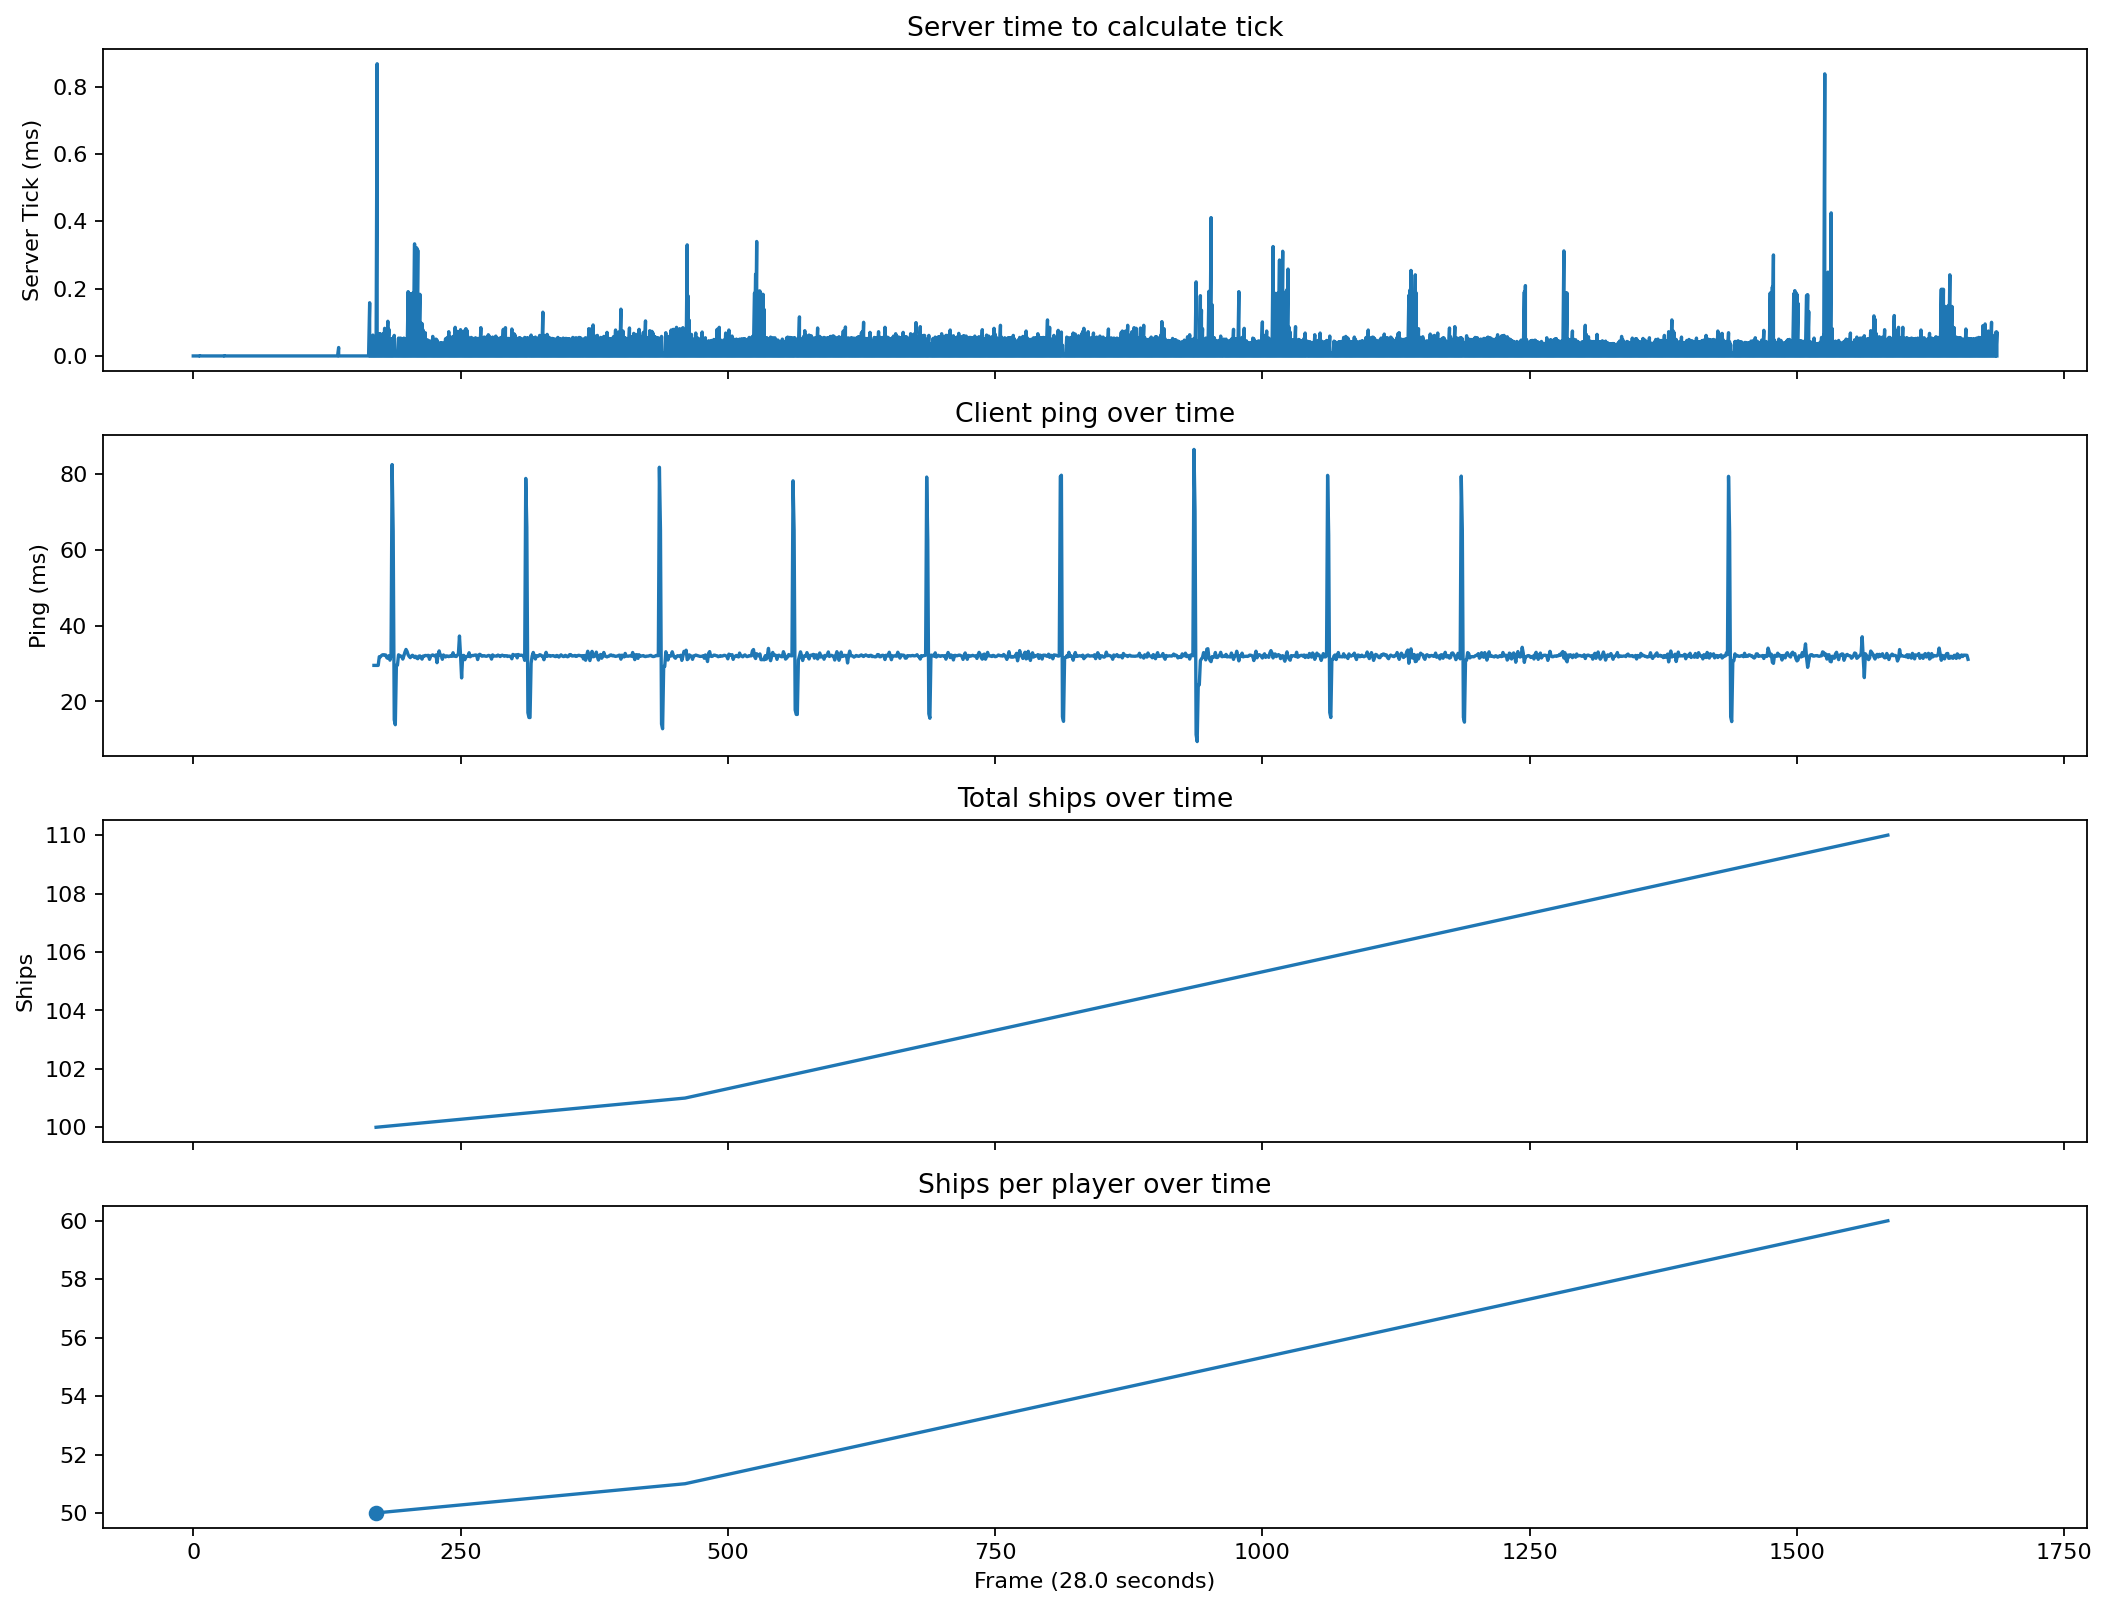

In [221]:
[ticks, pings, ships] = plot_all()

(array([1.000e+00, 1.000e+00, 2.000e+00, 6.000e+00, 1.100e+01, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00,
        3.000e+00, 6.500e+01, 1.205e+03, 1.680e+02, 3.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 3.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 7.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 9.384 , 10.9261, 12.4682, 14.0103, 15.5524, 17.0945, 18.6366,
        20.1787, 21.7208, 23.2629, 24.805 , 26.3471, 27.8892, 29.4313,
        30.9734, 32.5155, 34.0576, 35.5997, 37.1418, 38.6839, 40.226 ,
        41.7681, 43.3102, 44.8523, 46.3944, 47.9365, 49.4786, 51.0207,
        52.5628, 54.1049, 55.647 , 57.1891, 58.7312, 60.2733, 61.8154,
        63.3575, 64.8

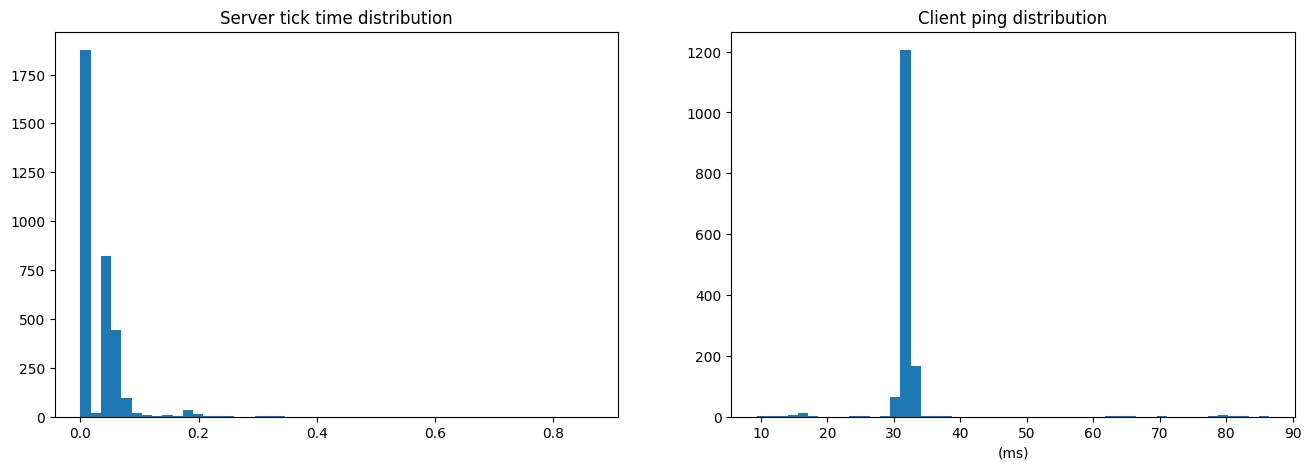

In [222]:
fig, axes = plt.subplots(1,2, figsize=(16, 5))
axes[0].set_title("Server tick time distribution")
axes[0].hist(ticks["y"], bins=50)
axes[1].set_xlabel("(ms)")
axes[1].set_title("Client ping distribution")
axes[1].set_xlabel("(ms)")
axes[1].hist(pings["y"], bins=50)